In [1]:
%pip install astroquery

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 49.6 MB/s eta 0:00:00


In [6]:
%pip install ipyaladin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 40.4 MB/s eta 0:00:00


In [7]:
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import ipyaladin as ipyal

In [ ]:
TARGET_NAME = "Cyg X-2"
SEARCH_RADIUS_DEG = 5.5

target_coor = SkyCoord.from_name(TARGET_NAME)
ra_deg = target_coor.ra.deg
dec_deg = target_coor.dec.deg
print(f"Coordinates for {TARGET_NAME}: {ra_deg:.4f}, {dec_deg:.4f} (deg)")


adql_query = f"""
SELECT
    s.source_id, s.ra, s.dec, s.parallax, s.parallax_error,
    s.pmra, s.pmdec, s.pmra_error, s.pmdec_error, s.phot_g_mean_mag, s.bp_rp
FROM
    gaiadr3.gaia_source AS s
JOIN
    gaiadr3.agn_cross_id AS agn ON s.source_id = agn.source_id
WHERE
    DISTANCE({ra_deg}, {dec_deg}, s.ra, s.dec) < {SEARCH_RADIUS_DEG}
    AND s.bp_rp IS NOT NULL
    AND ABS(s.pmra / s.pmra_error) <= 3
    AND ABS(s.pmdec / s.pmdec_error) <= 3
"""

job = Gaia.launch_job_async(adql_query)
gaia_quasars = job.get_results()
print(f"Found {len(gaia_quasars)} Gaia quasars")

In [8]:
aladin = ipyal.Aladin(
    target=TARGET_NAME,
    fov=12,
    survey="P/DSS2/color",
    height=800
)
display(aladin)

if len(gaia_quasars) > 0:
    aladin.add_table(
        gaia_quasars,
        name="Gaia DR3 Quasars (agn_cross_id)",
        color="red",
        shape="circle",
        source_size=10
    )

target_marker = ipyal.Marker(
    position=target_coor,
    title=TARGET_NAME,
    description="Your LMXB target",
)
aladin.add_markers([target_marker], color="#00FF00", shape="cross", source_size=25)

In [9]:

valid_mask = ~np.isnan(gaia_quasars['parallax']) & ~np.isnan(gaia_quasars['parallax_error'])
clean_quasars = gaia_quasars[valid_mask]

parallaxes = clean_quasars['parallax'].data
errors = clean_quasars['parallax_error'].data

weights = 1.0 / (errors ** 2)

weighted_mean_parallax = np.sum(parallaxes * weights) / np.sum(weights)

formal_uncertainty = np.sqrt(1.0 / np.sum(weights))

print("--- Parallax Zero Point Estimation (Simple Spatial Filter) ---")
print(f"Quasars evaluated: {len(clean_quasars)}")
print(f"Weighted Mean Parallax (w_0): {weighted_mean_parallax:.4f} mas")
print(f"Formal Uncertainty (sigma_w0): {formal_uncertainty:.4f} mas")

--- Parallax Zero Point Estimation (Simple Spatial Filter) ---
Quasars evaluated: 1812
Weighted Mean Parallax (w_0): -0.0149 mas
Formal Uncertainty (sigma_w0): 0.0058 mas


In [10]:
TARGET_NAME = "Cyg X-2"
SIN_BETA_TARGET = 0.74
DELTA_SIN_BETA = 0.02

MG_TARGET = 14.70
DELTA_MG_REL = 0.316

MBR_TARGET = 0.71
DELTA_MBR = 0.09


ra = clean_quasars['ra'].data * u.deg
dec = clean_quasars['dec'].data * u.deg
mg = clean_quasars['phot_g_mean_mag'].data
mbr = clean_quasars['bp_rp'].data

coords = SkyCoord(ra=ra, dec=dec, frame='icrs')
ecliptic_coords = coords.transform_to('barycentrictrueecliptic')
sin_beta = np.sin(ecliptic_coords.lat.rad)

# A. Ecliptic Latitude Filter
mask_beta = np.abs(sin_beta - SIN_BETA_TARGET) <= DELTA_SIN_BETA

# B. Magnitude Filter
mask_mg = np.abs(mg - MG_TARGET) <= (MG_TARGET * DELTA_MG_REL)

# C. Color Filter
mask_mbr = np.abs(mbr - MBR_TARGET) <= DELTA_MBR

final_mask = mask_beta & mask_mg & mask_mbr
filtered_quasars = clean_quasars[final_mask]

parallaxes = filtered_quasars['parallax'].data
errors = filtered_quasars['parallax_error'].data
weights = 1.0 / (errors ** 2)

refined_w0 = np.sum(parallaxes * weights) / np.sum(weights)
refined_err = np.sqrt(1.0 / np.sum(weights))

print("--- REFINED Parallax Zero Point (Ding 2021 Filters) ---")
print(f"Surviving Quasars: {len(filtered_quasars)}")
print(f"Refined Zero Point (w_0): {refined_w0:.4f} mas")
print(f"Formal Uncertainty (sigma_w0): {refined_err:.4f} mas")

print("\nRe-initializing Aladin Lite with filtered quasars...")
target_coor = SkyCoord.from_name(TARGET_NAME)

aladin_refined = ipyal.Aladin(
    target=TARGET_NAME,
    fov=12,
    survey="P/DSS2/color",
    height=800
)
display(aladin_refined)

if len(filtered_quasars) > 0:
    aladin_refined.add_table(
        filtered_quasars,
        name="Filtered Representative Quasars",
        color="orange",
        shape="circle",
        source_size=15
    )

target_marker = ipyal.Marker(
    position=target_coor,
    title=TARGET_NAME,
    description="Your LMXB target",
)
aladin_refined.add_markers([target_marker], color="#00FF00", shape="cross", source_size=25)

--- REFINED Parallax Zero Point (Ding 2021 Filters) ---
Surviving Quasars: 37
Refined Zero Point (w_0): 0.0317 mas
Formal Uncertainty (sigma_w0): 0.0255 mas

Re-initializing Aladin Lite with filtered quasars...


<>:66: SyntaxWarning: invalid escape sequence '\m'
<>:66: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_12117/1772078694.py:66: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$P(r \mid \omega, \sigma_\omega)$ [Normalized]")


Querying Gaia DR3 for source 1952859683185470208...


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
Raw Parallax: 0.0684 ± 0.0191 mas
Calibrated Parallax (omega): 0.0367 mas

---> Inferred Distance (Posterior Mode): 13329.35 pc


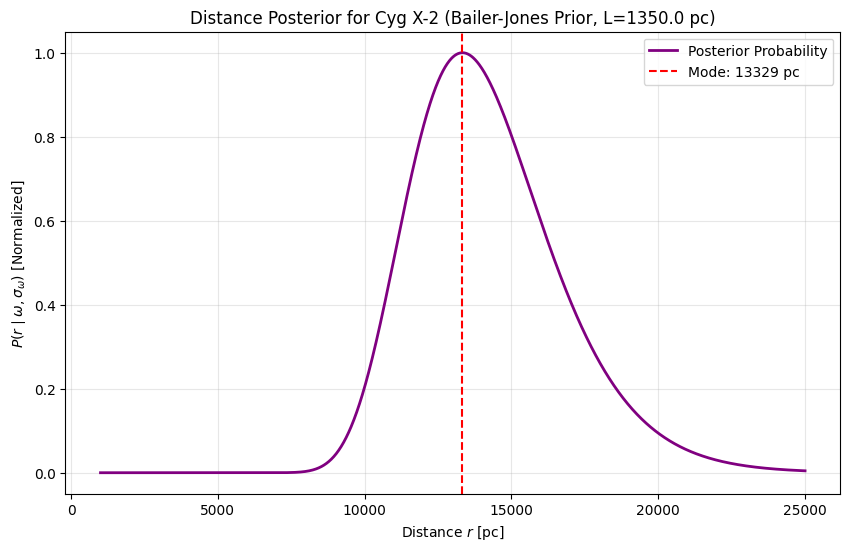

In [11]:
# from https://github.com/logan-pearce/breakthroughlisten/blob/master/Computing%20distance%20with%20Gaia%20parallaxes%20tutorial.ipynb

TARGET_SOURCE_ID = 1952859683185470208 # Cyg X-2
ZERO_POINT_MAS = 0.0317
L = 1350.0

print(f"Querying Gaia DR3 for source {TARGET_SOURCE_ID}...")
query = f"""
SELECT parallax, parallax_error
FROM gaiadr3.gaia_source
WHERE source_id = {TARGET_SOURCE_ID}
"""
job = Gaia.launch_job_async(query)
res = job.get_results()

raw_parallax = res['parallax'][0]
parallax_error = res['parallax_error'][0]

print(f"Raw Parallax: {raw_parallax:.4f} ± {parallax_error:.4f} mas")

calibrated_parallax = raw_parallax - ZERO_POINT_MAS

omega = calibrated_parallax / 1000.0
sigma = parallax_error / 1000.0

print(f"Calibrated Parallax (omega): {omega*1000:.4f} mas")


coeff = np.array([
    (1. / L),
    -2.0,
    (omega / sigma**2),
    -(1. / sigma**2)
])

roots = np.roots(coeff)

real_roots = roots[np.isreal(roots)].real

if len(real_roots) == 1:
    mode_distance = real_roots[0]
elif len(real_roots) == 3:
    if omega >= 0:
        mode_distance = np.min(real_roots)
    else:
        mode_distance = real_roots[real_roots > 0][0] # Take the positive root
else:
    mode_distance = np.nan

print(f"\n---> Inferred Distance (Posterior Mode): {mode_distance:.2f} pc")


r = np.linspace(1000, 25000, 2000)


posterior = (r**2 * np.exp(-r/L) / sigma) * np.exp((-1.0 / (2 * sigma**2)) * (omega - (1.0/r))**2)

posterior_normalized = posterior / np.max(posterior)

plt.figure(figsize=(10, 6))
plt.plot(r, posterior_normalized, label="Posterior Probability", color="purple", lw=2)
plt.axvline(x=mode_distance, color="red", linestyle="--", label=f"Mode: {mode_distance:.0f} pc")

plt.title(f"Distance Posterior for Cyg X-2 (Bailer-Jones Prior, L={L} pc)")
plt.xlabel("Distance $r$ [pc]")
plt.ylabel("$P(r \mid \omega, \sigma_\omega)$ [Normalized]")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


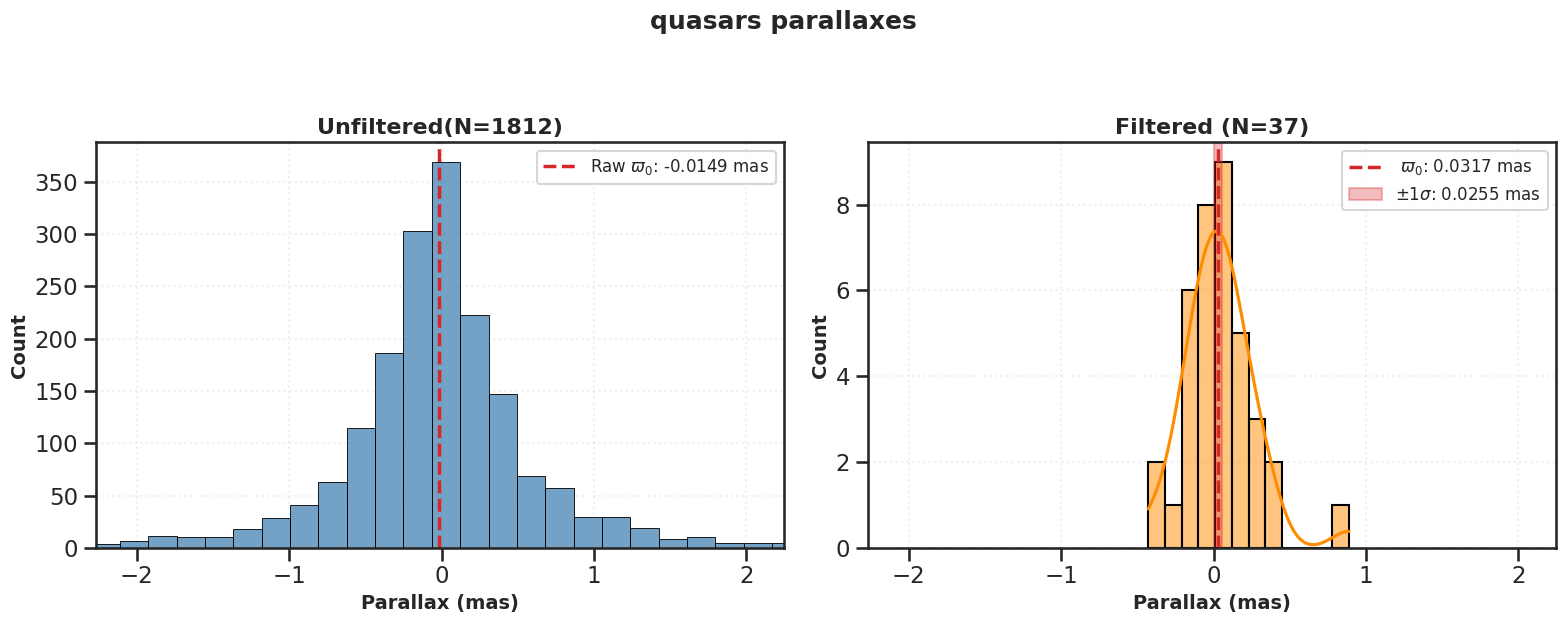

In [13]:


unfiltered_parallaxes = clean_quasars['parallax'].data
filtered_parallaxes = filtered_quasars['parallax'].data

sns.set_theme(style="ticks", context="talk")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


sns.histplot(
    unfiltered_parallaxes,
    bins=60,
    color="steelblue",
    edgecolor="black",
    ax=ax1
)

ax1.axvline(
    weighted_mean_parallax,
    color='#d62728',
    linestyle='--',
    linewidth=2.5,
    label=f'Raw $\\varpi_0$: {weighted_mean_parallax:.4f} mas'
)

ax1.set_title(f"Unfiltered(N={len(clean_quasars)})", fontsize=16, fontweight='bold')
ax1.set_xlabel("Parallax (mas)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Count", fontsize=14, fontweight='bold')

p1, p99 = np.percentile(unfiltered_parallaxes, [1, 99])
ax1.set_xlim(p1, p99)
ax1.legend(loc='upper right', frameon=True, fontsize=12)
ax1.grid(alpha=0.3, linestyle=':')

sns.histplot(
    filtered_parallaxes,
    bins=12,
    color="darkorange",
    edgecolor="black",
    kde=True,
    ax=ax2
)

ax2.axvline(
    refined_w0,
    color='#d62728',
    linestyle='--',
    linewidth=2.5,
    label=f' $\\varpi_0$: {refined_w0:.4f} mas'
)

ax2.axvspan(
    refined_w0 - refined_err,
    refined_w0 + refined_err,
    color='#d62728',
    alpha=0.3,
    label=f'$\\pm 1\\sigma$: {refined_err:.4f} mas'
)

ax2.set_title(f"Filtered (N={len(filtered_quasars)})", fontsize=16, fontweight='bold')
ax2.set_xlabel("Parallax (mas)", fontsize=14, fontweight='bold')
ax2.set_ylabel("Count", fontsize=14, fontweight='bold')

ax2.set_xlim(p1, p99)
ax2.legend(loc='upper right', frameon=True, fontsize=12)
ax2.grid(alpha=0.3, linestyle=':')


plt.suptitle(
    "quasars parallaxes",
    fontsize=18,
    fontweight='bold',
    y=1.05
)

plt.tight_layout()
plt.savefig("quasar_parallax_distributions.png", dpi=300, bbox_inches='tight')
plt.show()

# Simpler

In [14]:
SEARCH_RADIUS_DEG = 8.06

TARGETS = {
    "Cen X-4":      None,
    "Cyg X-2":      None,
    "4U 0919-54":   None,
    "XB 2129+47":   None,
    "NP Ser":       None,
}

results = {}

for target_name in TARGETS:
    print(f"\n{'='*50}")
    print(f"Processing: {target_name}")

    target_coord = SkyCoord.from_name(target_name)
    ra_deg  = target_coord.ra.deg
    dec_deg = target_coord.dec.deg
    print(f"  Coordinates: RA={ra_deg:.4f}, Dec={dec_deg:.4f}")

    adql_query = f"""
    SELECT
        s.source_id, s.ra, s.dec,
        s.parallax, s.parallax_error,
        s.pmra, s.pmdec, s.pmra_error, s.pmdec_error,
        s.phot_g_mean_mag, s.bp_rp
    FROM
        gaiadr3.gaia_source AS s
    JOIN
        gaiadr3.agn_cross_id AS agn ON s.source_id = agn.source_id
    WHERE
        DISTANCE({ra_deg}, {dec_deg}, s.ra, s.dec) < {SEARCH_RADIUS_DEG}
        AND s.bp_rp IS NOT NULL
        AND ABS(s.pmra  / s.pmra_error)  <= 3
        AND ABS(s.pmdec / s.pmdec_error) <= 3
    """

    job = Gaia.launch_job_async(adql_query)
    quasars = job.get_results()
    print(f"  Raw quasars found: {len(quasars)}")

    # clean NaNs
    valid = ~np.isnan(quasars['parallax']) & ~np.isnan(quasars['parallax_error'])
    clean = quasars[valid]
    print(f"  Clean quasars (no NaN): {len(clean)}")

    parallaxes = clean['parallax'].data
    errors     = clean['parallax_error'].data
    weights    = 1.0 / errors**2

    pi0       = np.sum(parallaxes * weights) / np.sum(weights)
    sigma_pi0 = np.sqrt(1.0 / np.sum(weights))

    results[target_name] = {
        'n_quasars': len(clean),
        'pi0':       pi0,
        'sigma_pi0': sigma_pi0,
    }

    print(f"  Zero-point pi0:        {pi0:.4f} mas")
    print(f"  Formal uncertainty:    {sigma_pi0:.4f} mas")

# summary table
print(f"\n{'='*50}")
print(f"{'Source':<20} {'N_quasars':>10} {'pi0 (mas)':>12} {'sigma (mas)':>12}")
print('-'*56)
for name, r in results.items():
    print(f"{name:<20} {r['n_quasars']:>10} {r['pi0']:>12.4f} {r['sigma_pi0']:>12.4f}")


Processing: Cen X-4
  Coordinates: RA=224.5914, Dec=-31.6688


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
  Raw quasars found: 5873
  Clean quasars (no NaN): 5873
  Zero-point pi0:        -0.0047 mas
  Formal uncertainty:    0.0047 mas

Processing: Cyg X-2
  Coordinates: RA=326.1715, Dec=38.3214


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
  Raw quasars found: 4067
  Clean quasars (no NaN): 4067
  Zero-point pi0:        -0.0197 mas
  Formal uncertainty:    0.0042 mas

Processing: 4U 0919-54
  Coordinates: RA=140.1103, Dec=-55.2068


...

INFO: Query finished. [astroquery.utils.tap.core]
  Raw quasars found: 746
  Clean quasars (no NaN): 746
  Zero-point pi0:        -0.0158 mas
  Formal uncertainty:    0.0090 mas

Processing: XB 2129+47
  Coordinates: RA=322.8592, Dec=47.2901


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
  Raw quasars found: 563
  Clean quasars (no NaN): 563
  Zero-point pi0:        -0.0163 mas
  Formal uncertainty:    0.0089 mas

Processing: NP Ser
  Coordinates: RA=274.0072, Dec=-14.0357


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
  Raw quasars found: 18
  Clean quasars (no NaN): 18
  Zero-point pi0:        0.0328 mas
  Formal uncertainty:    0.0658 mas

Source                N_quasars    pi0 (mas)  sigma (mas)
--------------------------------------------------------
Cen X-4                    5873      -0.0047       0.0047
Cyg X-2                    4067      -0.0197       0.0042
4U 0919-54                  746      -0.0158       0.0090
XB 2129+47                  563      -0.0163       0.0089
NP Ser                       18       0.0328       0.0658


In [15]:
SEARCH_RADIUS_DEG = 8.06

# means of table 3 in Ding
DELTA_SIN_BETA_MEAN = 0.074
DELTA_MG_REL_MEAN   = 0.153
DELTA_MBR_MEAN      = 0.678

TARGETS = {
    "Cen X-4":    {"sin_beta": -0.24, "mG": 17.85, "mBR": 1.59},
    "Cyg X-2":    {"sin_beta":  0.74, "mG": 14.70, "mBR": 0.71},
    "4U 0919-54": {"sin_beta": -0.90, "mG": 17.15, "mBR": 1.19},
    "XB 2129+47": {"sin_beta":  0.84, "mG": 17.58, "mBR": 1.29},
    "NP Ser":     {"sin_beta":  0.16, "mG": 17.01, "mBR": 1.51},
}

results = {}

for target_name, props in TARGETS.items():
    print(f"\n{'='*50}")
    print(f"Processing: {target_name}")

    target_coord = SkyCoord.from_name(target_name)
    ra_deg  = target_coord.ra.deg
    dec_deg = target_coord.dec.deg

    adql_query = f"""
    SELECT
        s.source_id, s.ra, s.dec,
        s.parallax, s.parallax_error,
        s.pmra, s.pmdec, s.pmra_error, s.pmdec_error,
        s.phot_g_mean_mag, s.bp_rp
    FROM
        gaiadr3.gaia_source AS s
    JOIN
        gaiadr3.agn_cross_id AS agn ON s.source_id = agn.source_id
    WHERE
        DISTANCE({ra_deg}, {dec_deg}, s.ra, s.dec) < {SEARCH_RADIUS_DEG}
        AND s.bp_rp IS NOT NULL
        AND ABS(s.pmra  / s.pmra_error)  <= 3
        AND ABS(s.pmdec / s.pmdec_error) <= 3
    """

    job = Gaia.launch_job_async(adql_query)
    quasars = job.get_results()

    valid = ~np.isnan(quasars['parallax']) & ~np.isnan(quasars['parallax_error'])
    clean = quasars[valid]
    print(f"  Spatial quasars (pre-filter): {len(clean)}")

    coords = SkyCoord(
        ra=clean['ra'].data * u.deg,
        dec=clean['dec'].data * u.deg,
        frame='icrs'
    )
    ecliptic = coords.transform_to('barycentrictrueecliptic')
    sin_beta = np.sin(ecliptic.lat.rad)

    mg  = clean['phot_g_mean_mag'].data
    mbr = clean['bp_rp'].data

    mask_beta = np.abs(sin_beta - props['sin_beta']) <= DELTA_SIN_BETA_MEAN
    mask_mg   = np.abs(mg  - props['mG'])            <= (props['mG'] * DELTA_MG_REL_MEAN)
    mask_mbr  = np.abs(mbr - props['mBR'])           <= DELTA_MBR_MEAN

    filtered = clean[mask_beta & mask_mg & mask_mbr]
    print(f"  Quasars after mean filters:   {len(filtered)}")

    parallaxes = filtered['parallax'].data
    errors     = filtered['parallax_error'].data
    weights    = 1.0 / errors**2

    pi0       = np.sum(parallaxes * weights) / np.sum(weights)
    sigma_pi0 = np.sqrt(1.0 / np.sum(weights))

    results[target_name] = {
        'n_pre':      len(clean),
        'n_filtered': len(filtered),
        'pi0':        pi0,
        'sigma_pi0':  sigma_pi0,
    }

    print(f"  Zero-point pi0:     {pi0:.4f} mas")
    print(f"  Formal uncertainty: {sigma_pi0:.4f} mas")

print(f"\n{'='*60}")
print(f"{'Source':<20} {'N_pre':>7} {'N_filt':>7} {'pi0 (mas)':>12} {'sigma':>10}")
print('-'*60)
for name, r in results.items():
    print(f"{name:<20} {r['n_pre']:>7} {r['n_filtered']:>7} "
          f"{r['pi0']:>12.4f} {r['sigma_pi0']:>10.4f}")


Processing: Cen X-4


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
  Spatial quasars (pre-filter): 5873
  Quasars after mean filters:   934
  Zero-point pi0:     -0.0007 mas
  Formal uncertainty: 0.0131 mas

Processing: Cyg X-2


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
  Spatial quasars (pre-filter): 4067
  Quasars after mean filters:   6
  Zero-point pi0:     -0.0138 mas
  Formal uncertainty: 0.0197 mas

Processing: 4U 0919-54


...

INFO: Query finished. [astroquery.utils.tap.core]
  Spatial quasars (pre-filter): 746
  Quasars after mean filters:   318
  Zero-point pi0:     -0.0182 mas
  Formal uncertainty: 0.0098 mas

Processing: XB 2129+47


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
  Spatial quasars (pre-filter): 563
  Quasars after mean filters:   308
  Zero-point pi0:     -0.0046 mas
  Formal uncertainty: 0.0130 mas

Processing: NP Ser


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
  Spatial quasars (pre-filter): 18
  Quasars after mean filters:   2
  Zero-point pi0:     0.0068 mas
  Formal uncertainty: 0.0719 mas

Source                 N_pre  N_filt    pi0 (mas)      sigma
------------------------------------------------------------
Cen X-4                 5873     934      -0.0007     0.0131
Cyg X-2                 4067       6      -0.0138     0.0197
4U 0919-54               746     318      -0.0182     0.0098
XB 2129+47               563     308      -0.0046     0.0130
NP Ser                    18       2       0.0068     0.0719


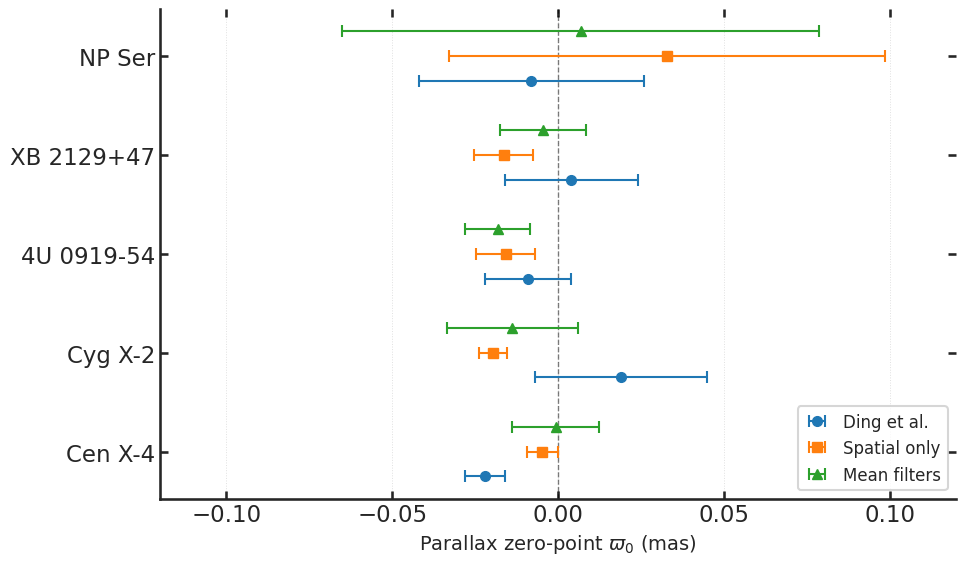

In [16]:
sources = ["Cen X-4", "Cyg X-2", "4U 0919-54", "XB 2129+47", "NP Ser"]

data = {
    "Ding et al.": {
        "pi0":   [-0.022,  0.019, -0.009,  0.004, -0.008],
        "sigma": [ 0.006,  0.026,  0.013,  0.020,  0.034],
    },
    "Spatial only": {
        "pi0":   [-0.0047, -0.0197, -0.0158, -0.0163,  0.0328],
        "sigma": [ 0.0047,  0.0042,  0.0090,  0.0089,  0.0658],
    },
    "Mean filters": {
        "pi0":   [-0.0007, -0.0138, -0.0182, -0.0046,  0.0068],
        "sigma": [ 0.0131,  0.0197,  0.0098,  0.0130,  0.0719],
    },
}

methods   = list(data.keys())
n_sources = len(sources)
n_methods = len(methods)

offsets = np.linspace(-0.25, 0.25, n_methods)
colors  = sns.color_palette("tab10", n_methods)
markers = ["o", "s", "^"]

sns.set_theme(style="ticks", context="talk")
fig, ax = plt.subplots(figsize=(10, 6))

for j, (method, color, marker, offset) in enumerate(zip(methods, colors, markers, offsets)):
    pi0   = np.array(data[method]["pi0"])
    sigma = np.array(data[method]["sigma"])
    y_pos = np.arange(n_sources) + offset

    ax.errorbar(
        pi0, y_pos,
        xerr=sigma,
        fmt=marker,
        color=color,
        ecolor=color,
        markersize=7,
        capsize=4,
        capthick=1.5,
        elinewidth=1.5,
        label=method,
        zorder=3,
    )

ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.5, zorder=1)

ax.set_yticks(np.arange(n_sources))
ax.set_yticklabels(sources)
ax.set_xlabel(r"Parallax zero-point $\varpi_0$ (mas)", fontsize=14)
ax.set_xlim(-0.12, 0.12)

ax.tick_params(axis="both", direction="in", top=True, right=True, length=6)
ax.grid(axis="x", linestyle=":", linewidth=0.7, alpha=0.6, zorder=0)

ax.legend(
    loc="lower right",
    frameon=True,
    fontsize=12,
    handlelength=1.5,
)

sns.despine()
plt.tight_layout()
plt.savefig("zeropoint_comparison.png", dpi=150)
plt.show()


Querying Cen X-4 (source_id=6205715168442046592)...


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
  Raw parallax:        0.5272 ± 0.1259 mas
  Ding zero-point:     -0.0220 mas
  Calibrated parallax: 0.5492 mas
  d (uncorrected):     1.96 kpc
  d (Ding-corrected):  1.88 kpc

Querying Cyg X-2 (source_id=1952859683185470208)...


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
  Raw parallax:        0.0684 ± 0.0191 mas
  Ding zero-point:     +0.0190 mas
  Calibrated parallax: 0.0494 mas
  d (uncorrected):     10.84 kpc
  d (Ding-corrected):  12.30 kpc

Querying 4U 0919-54 (source_id=5310395631798303104)...


...

INFO: Query finished. [astroquery.utils.tap.core]
  Raw parallax:        0.2357 ± 0.0606 mas
  Ding zero-point:     -0.0090 mas
  Calibrated parallax: 0.2447 mas
  d (uncorrected):     4.00 kpc
  d (Ding-corrected):  3.89 kpc

Querying XB 2129+47 (source_id=1978241050130301312)...


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
  Raw parallax:        0.5019 ± 0.0772 mas
  Ding zero-point:     +0.0040 mas
  Calibrated parallax: 0.4979 mas
  d (uncorrected):     2.02 kpc
  d (Ding-corrected):  2.03 kpc

Querying NP Ser (source_id=4146621775597340544)...


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
  Raw parallax:        0.6876 ± 0.0756 mas
  Ding zero-point:     -0.0080 mas
  Calibrated parallax: 0.6956 mas
  d (uncorrected):     1.47 kpc
  d (Ding-corrected):  1.45 kpc


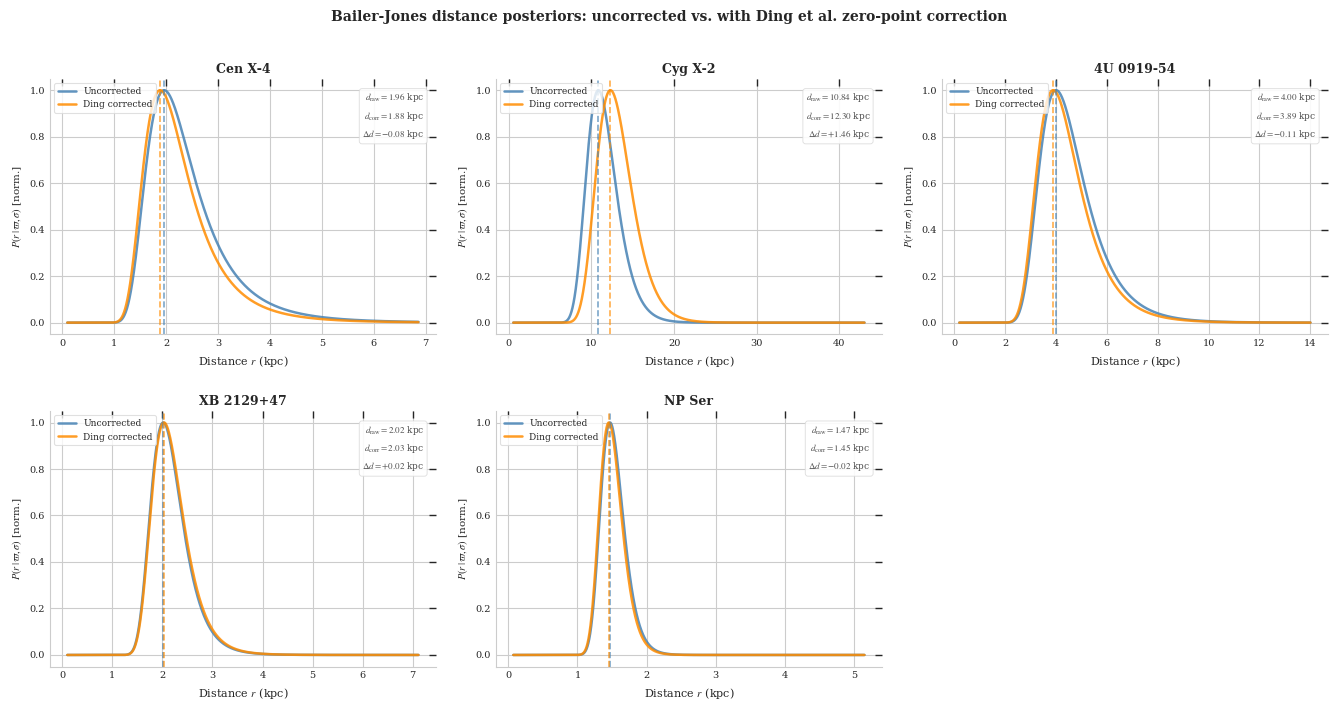


Source              w_raw      w_0     w_cal     d_raw    d_corr  delta d
---------------------------------------------------------------------------
  Cen X-4        +0.5272  -0.0220  +0.5492     1.96     1.88   -0.08  kpc
  Cyg X-2        +0.0684  +0.0190  +0.0494    10.84    12.30   +1.46  kpc
  4U 0919-54     +0.2357  -0.0090  +0.2447     4.00     3.89   -0.11  kpc
  XB 2129+47     +0.5019  +0.0040  +0.4979     2.02     2.03   +0.02  kpc
  NP Ser         +0.6876  -0.0080  +0.6956     1.47     1.45   -0.02  kpc


In [23]:
# BAILER-JONES DISTANCE INFERENCE FOR 5 DING ET AL. SOURCES
import math
sources_ding = {
    "Cen X-4":    {"source_id": 6205715168442046592, "zp_ding": -0.022, "L": 1350.0},
    "Cyg X-2":    {"source_id": 1952859683185470208, "zp_ding": +0.019, "L": 1350.0},
    "4U 0919-54": {"source_id": 5310395631798303104, "zp_ding": -0.009, "L": 1350.0},
    "XB 2129+47": {"source_id": 1978241050130301312, "zp_ding": +0.004, "L": 1350.0},
    "NP Ser":     {"source_id": 4146621775597340544, "zp_ding": -0.008, "L": 1350.0},
}

def bailer_jones_mode(omega, sigma, L):
    """Compute posterior mode distance (pc) using Bailer-Jones DR2 prior."""
    coeff = np.array([
        1.0 / L,
        -2.0,
        omega / sigma**2,
        -1.0 / sigma**2
    ])
    roots = np.roots(coeff)
    real_roots = roots[np.isreal(roots)].real
    real_roots = real_roots[real_roots > 0]

    if len(real_roots) == 1:
        return real_roots[0]
    elif len(real_roots) >= 2:
        return np.min(real_roots) if omega >= 0 else real_roots[0]
    return np.nan

def bailer_jones_posterior(r, omega, sigma, L):
    return r**2 * np.exp(-r / L) * np.exp(-0.5 * ((omega - 1.0/r) / sigma)**2)

# fetch parallaxes and infer d
results_zp = {}

for name, info in sources_ding.items():
    print(f"\nQuerying {name} (source_id={info['source_id']})...")
    query = f"""
        SELECT parallax, parallax_error
        FROM gaiadr3.gaia_source
        WHERE source_id = {info['source_id']}
    """
    job = Gaia.launch_job_async(query)
    res = job.get_results()

    raw_plx = float(res['parallax'][0])
    plx_err = float(res['parallax_error'][0])

    # uncorrected
    omega_raw   = raw_plx / 1000.0          # mas to arcsec
    sigma       = plx_err / 1000.0
    d_raw       = bailer_jones_mode(omega_raw, sigma, info['L'])

    # Ding-corrected
    cal_plx     = raw_plx - info['zp_ding']
    omega_cal   = cal_plx / 1000.0
    d_corrected = bailer_jones_mode(omega_cal, sigma, info['L'])

    results_zp[name] = {
        "raw_plx":     raw_plx,
        "plx_err":     plx_err,
        "zp_ding":     info['zp_ding'],
        "cal_plx":     cal_plx,
        "d_raw_pc":    d_raw,
        "d_corr_pc":   d_corrected,
        "d_raw_kpc":   d_raw   / 1000.0,
        "d_corr_kpc":  d_corrected / 1000.0,
        "L":           info['L'],
        "omega_raw":   omega_raw,
        "omega_cal":   omega_cal,
        "sigma":       sigma,
    }

    print(f"  Raw parallax:        {raw_plx:.4f} ± {plx_err:.4f} mas")
    print(f"  Ding zero-point:     {info['zp_ding']:+.4f} mas")
    print(f"  Calibrated parallax: {cal_plx:.4f} mas")
    print(f"  d (uncorrected):     {d_raw/1000:.2f} kpc")
    print(f"  d (Ding-corrected):  {d_corrected/1000:.2f} kpc")

# plot comparaison
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({"font.family": "serif", "axes.linewidth": 0.8})

n = len(sources_ding)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 3.5))
axes = axes.flatten()

for ax, (name, r) in zip(axes, results_zp.items()):
    L       = r['L']
    sigma   = r['sigma']


    d_max   = max(r['d_raw_pc'], r['d_corr_pc']) * 3.5
    d_min   = max(10, min(r['d_raw_pc'], r['d_corr_pc']) * 0.05)
    dist_grid = np.linspace(d_min, d_max, 3000)

    post_raw  = bailer_jones_posterior(dist_grid, r['omega_raw'], sigma, L)
    post_corr = bailer_jones_posterior(dist_grid, r['omega_cal'], sigma, L)
    post_raw  /= np.max(post_raw)
    post_corr /= np.max(post_corr)

    ax.plot(dist_grid / 1000, post_raw,
            color='steelblue', lw=1.8, label='Uncorrected', alpha=0.85)
    ax.plot(dist_grid / 1000, post_corr,
            color='darkorange', lw=1.8, label='Ding corrected', alpha=0.85)

    ax.axvline(r['d_raw_kpc'],  color='steelblue',  lw=1.2, linestyle='--', alpha=0.7)
    ax.axvline(r['d_corr_kpc'], color='darkorange', lw=1.2, linestyle='--', alpha=0.7)

    ax.set_title(name, fontsize=9, fontweight='bold', pad=4)
    ax.set_xlabel(r'Distance $r$ (kpc)', fontsize=8)
    ax.set_ylabel(r'$P(r\,|\,\varpi,\sigma)$ [norm.]', fontsize=7.5)
    ax.tick_params(labelsize=7, direction='in', top=True, right=True)

    delta = r['d_corr_kpc'] - r['d_raw_kpc']
    ax.text(0.97, 0.95,
            f"$d_{{\\rm raw}} = {r['d_raw_kpc']:.2f}$ kpc\n"
            f"$d_{{\\rm corr}} = {r['d_corr_kpc']:.2f}$ kpc\n"
            f"$\\Delta d = {delta:+.2f}$ kpc",
            transform=ax.transAxes, fontsize=6.5,
            ha='right', va='top', color='0.3', linespacing=1.6,
            bbox=dict(boxstyle='round,pad=0.3', fc='white',
                      ec='0.85', lw=0.6, alpha=0.9))

    ax.legend(fontsize=6.5, framealpha=0.8, edgecolor='0.85', loc='upper left')

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle(
    r'Bailer-Jones distance posteriors: uncorrected vs. with Ding et al. zero-point correction',
    fontsize=10, fontweight='bold', y=1.01
)
sns.despine(left=False, bottom=False)
plt.tight_layout(pad=1.2, h_pad=2.0, w_pad=1.5)
plt.savefig('zeropoint_distances.png', dpi=200, bbox_inches='tight')
plt.show()


print(f"\n{'Source':<15s}  {'w_raw':>8s}  {'w_0':>7s}  "
      f"{'w_cal':>8s}  {'d_raw':>8s}  {'d_corr':>8s}  {'delta d':>7s}")
print("-" * 75)
for name, r in results_zp.items():
    delta = r['d_corr_kpc'] - r['d_raw_kpc']
    print(f"  {name:<13s}  {r['raw_plx']:>+7.4f}  {r['zp_ding']:>+6.4f}  "
          f"{r['cal_plx']:>+7.4f}  {r['d_raw_kpc']:>7.2f}  "
          f"{r['d_corr_kpc']:>7.2f}  {delta:>+6.2f}  kpc")